In [1]:
import os
os.chdir('..')

# Import Files

In [ ]:
from src.data.price_data import YahooFinance
from src.robust.prior import PriorStudentDistribution
from src.data.bootstrap import generate_path

In [3]:
start_date='1995-01-01'
end_date='2023-12-31'
yf = YahooFinance('SPY', start_date=start_date, end_date=end_date)
df = yf.pipeline()
df.head(5)

[*********************100%***********************]  1 of 1 completed


,price,normalized_price,log_price,log_return
date,,,,
1995-01-03,26.511950,1.000000,3.277596,NaN
1995-01-04,26.638632,1.004778,3.282362,0.004767
1995-01-05,26.638632,1.004778,3.282362,0.000000
1995-01-06,26.665779,1.005802,3.283381,0.001019
1995-01-09,26.692930,1.006826,3.284399,0.001018


In [4]:
asset_returns = df['log_return'].dropna().to_numpy()
total_paths = 50
seed = 123
bootstrap_paths = generate_path(asset_returns, total_paths, 1000, seed)
bootstrap_paths

array([[-0.00086944,  0.00154584, -0.00678887, ...,  0.00465992,
        -0.00066462, -0.00066506],
       [ 0.00842012,  0.00279124, -0.01177478, ...,  0.01283494,
        -0.00292667,  0.00598255],
       [-0.01617856,  0.00751878,  0.02340053, ..., -0.01324106,
         0.00550019, -0.00412197],
       ...,
       [-0.00118287,  0.00746616, -0.01555139, ..., -0.01534722,
         0.01822899, -0.004991  ],
       [ 0.00041112,  0.0160136 , -0.00074182, ...,  0.00139768,
        -0.01959965, -0.00337974],
       [-0.01551079,  0.00282985,  0.00853028, ..., -0.00266489,
         0.00980542,  0.01004448]], shape=(50, 1000))

In [5]:
prior_params = {
    'n_samples': 1000,
    'mu': 0.0,
    'scale': 0.03,
    'ddof': 2
}

prior_measure = PriorStudentDistribution(**prior_params)
prior_measure_support = prior_measure.sample_from_support(total_paths).numpy()
prior_measure_support

array([[-0.67014956, -0.47315526, -0.3857478 , ...,  0.3857478 ,
         0.47315526,  0.67014956],
       [-0.67014956, -0.47315526, -0.3857478 , ...,  0.3857478 ,
         0.47315526,  0.67014956],
       [-0.67014956, -0.47315526, -0.3857478 , ...,  0.3857478 ,
         0.47315526,  0.67014956],
       ...,
       [-0.67014956, -0.47315526, -0.3857478 , ...,  0.3857478 ,
         0.47315526,  0.67014956],
       [-0.67014956, -0.47315526, -0.3857478 , ...,  0.3857478 ,
         0.47315526,  0.67014956],
       [-0.67014956, -0.47315526, -0.3857478 , ...,  0.3857478 ,
         0.47315526,  0.67014956]], shape=(50, 1000), dtype=float32)

In [6]:
from scipy.stats import wasserstein_distance
wd = np.array([wasserstein_distance(i, j) for i, j in zip(bootstrap_paths, prior_measure_support)])
wd

array([0.03202968, 0.03311452, 0.03282766, 0.03276209, 0.03266324,
       0.03180461, 0.03189587, 0.03268872, 0.03248254, 0.03228935,
       0.03313508, 0.03151539, 0.03313926, 0.03240674, 0.03098898,
       0.03302954, 0.03169672, 0.03199823, 0.03201388, 0.03156335,
       0.0328656 , 0.03301053, 0.03248569, 0.0324317 , 0.03297364,
       0.0318799 , 0.03034744, 0.03226531, 0.03263747, 0.03263679,
       0.0327079 , 0.03308027, 0.03227162, 0.0316343 , 0.03200929,
       0.03246078, 0.03165149, 0.03223635, 0.03225608, 0.03283498,
       0.0322922 , 0.0327037 , 0.03248868, 0.03200088, 0.03225849,
       0.03293368, 0.03132904, 0.03175936, 0.03194068, 0.0324424 ])

In [7]:
from scipy.stats import t
# 1️⃣ generate big prior sample
big_prior = t.rvs(df=2, loc=0, scale=0.03, size=1000)

# 2️⃣ compute prior quantile grid
u = np.linspace(0,1,1000)
prior_q = np.quantile(big_prior, u)

# 3️⃣ sort bootstrap paths
boot_sorted = np.sort(bootstrap_paths, axis=1)

# 4️⃣ compute vectorised W1
distances = np.mean(np.abs(boot_sorted - prior_q), axis=1)

# 5️⃣ take quantile
epsilon_hat = np.quantile(distances, 0.95)
epsilon_hat

np.float64(0.03255347502269511)

In [8]:
from scipy.stats import t
from scipy.special import stdtrit

# ── Method 1: MLE on raw returns (fixing mu=0) ───────────────────────────────
ddof_mle, _, scale_mle = t.fit(asset_returns, floc=0)
print(f"MLE  →  ddof={ddof_mle:.4f}  scale={scale_mle:.6f}")

prior_mle = PriorStudentDistribution(n_samples=1000, mu=0.0, scale=scale_mle, ddof=ddof_mle)
print(prior_mle.support.numpy()[[0, 500, -1]])  # sanity-check support

MLE  →  ddof=2.8875  scale=0.007366
[-7.9731375e-02  1.0040872e-05  7.9731375e-02]


## Method 2: Robust fit via Wasserstein distance on bootstrap paths

Minimise the mean W1 distance between the prior quantile grid and each bootstrap path, fixing `mu=0`. This yields params that best describe the *distribution of paths* rather than the raw data points.

In [9]:
from scipy.optimize import minimize

# Quantile grid matching PriorStudentDistribution._build_support (mu=0 fixed)
n_q = 1000
u = np.linspace(0, 1, n_q + 2)[1:-1]   # (n_q,) — same grid as the class
boot_sorted = np.sort(bootstrap_paths, axis=1)  # (n_sims, n_q)

def mean_w1(params):
    """Mean W1 across bootstrap paths between prior quantile grid and each path."""
    log_ddof, log_scale = params
    ddof  = np.exp(log_ddof)
    scale = np.exp(log_scale)
    prior_q = stdtrit(ddof, u) * scale   # (n_q,) quantile grid, mu=0
    return np.mean(np.abs(boot_sorted - prior_q))  # mean over paths and quantiles

# Optimise in log-space so ddof>0 and scale>0 are enforced naturally
x0 = [np.log(3.0), np.log(0.01)]   # warm start near a typical t-fit
result = minimize(mean_w1, x0, method="Nelder-Mead",
                  options={"xatol": 1e-6, "fatol": 1e-8, "maxiter": 5000})

ddof_rob  = np.exp(result.x[0])
scale_rob = np.exp(result.x[1])
print(f"Robust  →  ddof={ddof_rob:.4f}  scale={scale_rob:.6f}  W1={result.fun:.6f}")

prior_robust = PriorStudentDistribution(n_samples=1000, mu=0.0, scale=scale_rob, ddof=ddof_rob)

Robust  →  ddof=3.2195  scale=0.007845  W1=0.001075


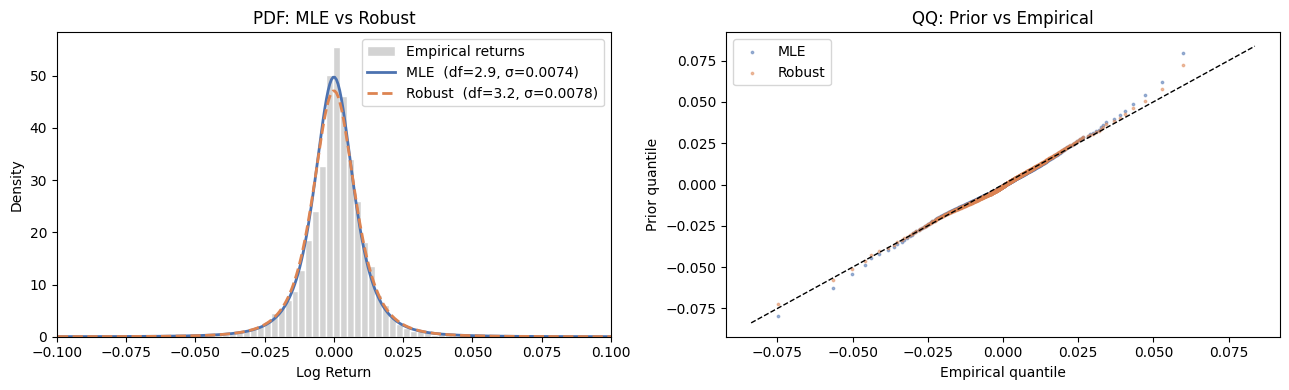

In [10]:
import matplotlib.pyplot as plt

x_grid = np.linspace(-0.15, 0.15, 500)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Left: PDF comparison ──────────────────────────────────────────────────────
axes[0].hist(asset_returns, bins=100, density=True, color="lightgray",
             edgecolor="white", label="Empirical returns")
axes[0].plot(x_grid, t.pdf(x_grid, df=ddof_mle,  loc=0, scale=scale_mle),
             color="#4C72B0", linewidth=2, label=f"MLE  (df={ddof_mle:.1f}, σ={scale_mle:.4f})")
axes[0].plot(x_grid, t.pdf(x_grid, df=ddof_rob,  loc=0, scale=scale_rob),
             color="#DD8452", linewidth=2, linestyle="--",
             label=f"Robust  (df={ddof_rob:.1f}, σ={scale_rob:.4f})")
axes[0].set_xlim(-0.1, 0.1)
axes[0].set_xlabel("Log Return")
axes[0].set_ylabel("Density")
axes[0].set_title("PDF: MLE vs Robust")
axes[0].legend()

# ── Right: QQ-plot of prior support vs empirical quantiles ───────────────────
emp_q = np.quantile(asset_returns, u)
axes[1].scatter(emp_q, prior_mle.support.numpy(),    s=3, alpha=0.5,
                color="#4C72B0", label="MLE")
axes[1].scatter(emp_q, prior_robust.support.numpy(), s=3, alpha=0.5,
                color="#DD8452", label="Robust")
lim = max(abs(emp_q).max(), abs(prior_mle.support.numpy()).max()) * 1.05
axes[1].plot([-lim, lim], [-lim, lim], "k--", linewidth=1)
axes[1].set_xlabel("Empirical quantile")
axes[1].set_ylabel("Prior quantile")
axes[1].set_title("QQ: Prior vs Empirical")
axes[1].legend()

plt.tight_layout()
plt.show()